# Jaselin V S

### Track: Data Analytics
### Task: Customer Segmentation Analysis — Oasis Infobyte SIP

# Customer Segmentation Analysis

**Objective:** This notebook applies clustering algorithms to segment an e-commerce company's customer base into distinct behavioral groups, based on purchasing patterns, to enable targeted marketing strategies.

**Dataset:** The Online Retail dataset (UCI), containing 525,461 transaction-level records from a UK-based online retailer, spanning roughly one year. After cleaning, 407,664 valid transactions across 4,312 unique customers were used for analysis.

**Approach:** The analysis proceeds through data cleaning, descriptive statistics, RFM (Recency, Frequency, Monetary) feature engineering, feature standardization, K-Means clustering with the Elbow Method to select the optimal number of clusters, cluster visualization and profiling, and concludes with segment-specific marketing recommendations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
import pandas as pd
df = pd.read_excel('online_retail_II.xlsx')

In [3]:
df.shape

(525461, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [6]:
df = df.dropna(subset=['Customer ID'])
df.shape

(417534, 8)

In [7]:
df['Quantity'].describe()

count    417534.000000
mean         12.758815
std         101.220424
min       -9360.000000
25%           2.000000
50%           4.000000
75%          12.000000
max       19152.000000
Name: Quantity, dtype: float64

In [8]:
df = df[df['Quantity'] > 0]
df.shape

(407695, 8)

In [9]:
df['Price'].describe()

count    407695.000000
mean          3.294188
std          34.756655
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: Price, dtype: float64

In [10]:
df = df[df['Price'] > 0]
df.shape

(407664, 8)

Data Cleaning Summary
The original dataset contained 525,461 rows. Rows with missing Customer ID (107,927) were removed since RFM analysis requires tracking individual customers. Rows with negative quantity (representing cancelled orders) and zero-price line items were also removed, as these don't represent genuine purchases. The cleaned dataset contains [X] rows, ready for RFM feature engineering.

In [11]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [12]:
order_totals = df.groupby('Invoice')['TotalPrice'].sum()
order_totals.describe()

count    19213.000000
mean       459.688923
std        931.129071
min          0.840000
25%        159.380000
50%        303.540000
75%        484.440000
max      44051.600000
Name: TotalPrice, dtype: float64

In [13]:
customer_frequency = df.groupby('Customer ID')['Invoice'].nunique()
customer_frequency.describe()

count    4312.000000
mean        4.455705
std         8.170213
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       205.000000
Name: Invoice, dtype: float64

In [14]:
customer_ltv = df.groupby('Customer ID')['TotalPrice'].sum()
customer_ltv.describe()

count      4312.000000
mean       2048.238236
std        8914.481280
min           2.950000
25%         307.987500
50%         706.020000
75%        1723.142500
max      349164.350000
Name: TotalPrice, dtype: float64

Descriptive Statistics Observations
Both order value and customer lifetime value are heavily right-skewed — most orders and customers are modest, but a small number of high-value orders/customers pull the averages well above the medians. Purchase frequency shows most customers (median = 2) are infrequent buyers, while a small number of highly engaged customers place many repeat orders (max = 205). This wide variation in customer behavior is exactly what makes segmentation valuable — a single average doesn't capture the real diversity of customer types in this data.

In [15]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2010-12-10 20:01:00')

In [16]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2048.238236
std,96.860633,8.170213,8914.481280
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.987500
50%,53.000000,2.000000,706.020000
75%,136.000000,5.000000,1723.142500
max,374.000000,205.000000,349164.350000


RFM Feature Engineering
Built a per-customer RFM table using a snapshot date of Dec 10, 2010 (one day after the last transaction). Recency, Frequency, and Monetary values all show the same right-skewed pattern seen earlier — most customers are moderately recent, infrequent, low-to-moderate spenders, while a smaller group of highly engaged, high-value customers pulls the averages upward. This spread is exactly what we want clustering to separate into distinct, actionable groups.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled

array([[ 0.76229851,  0.80108727, -0.18796074],
       [-0.91040156, -0.3006029 , -0.0813286 ],
       [-0.17730462, -0.42301292, -0.20486778],
       ...,
       [ 2.114914  , -0.42301292, -0.18188678],
       [ 0.21505713, -0.3006029 , -0.08434539],
       [-0.75552193, -0.05578286,  0.03337337]], shape=(4312, 3))

In [19]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

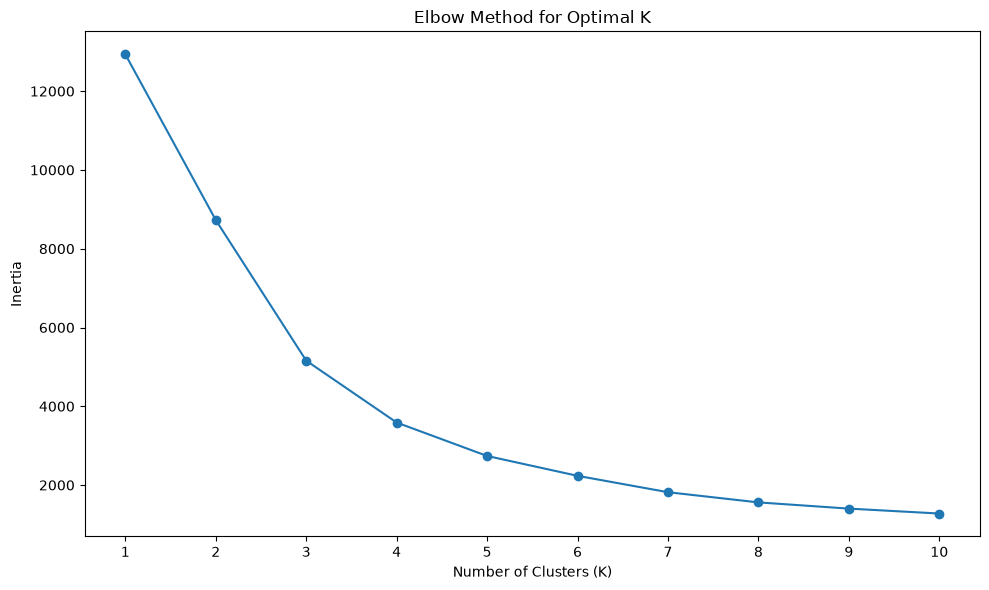

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

Elbow Method Observations
The elbow curve shows a sharp decrease in inertia from K=1 through K=4, after which the curve flattens significantly. This suggests K=4 is a good choice for the number of clusters — enough to meaningfully separate customer types, without over-segmenting into groups too granular to act on.

In [21]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,1
12347.0,3,2,1323.32,0
12348.0,74,1,222.16,0
12349.0,43,3,2671.14,0
12351.0,11,1,300.93,0


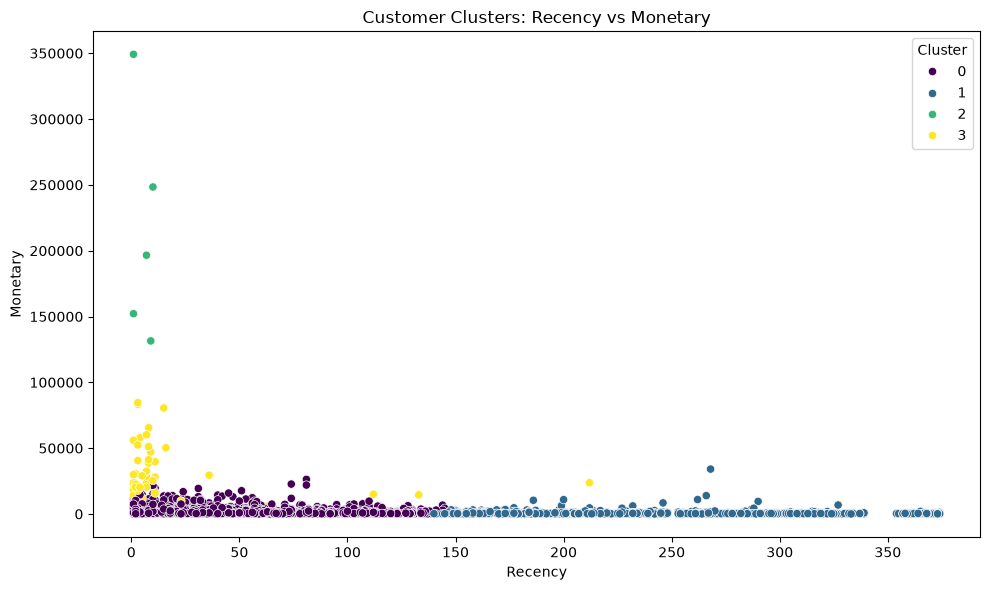

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Customer Clusters: Recency vs Monetary')
plt.tight_layout()
plt.show()

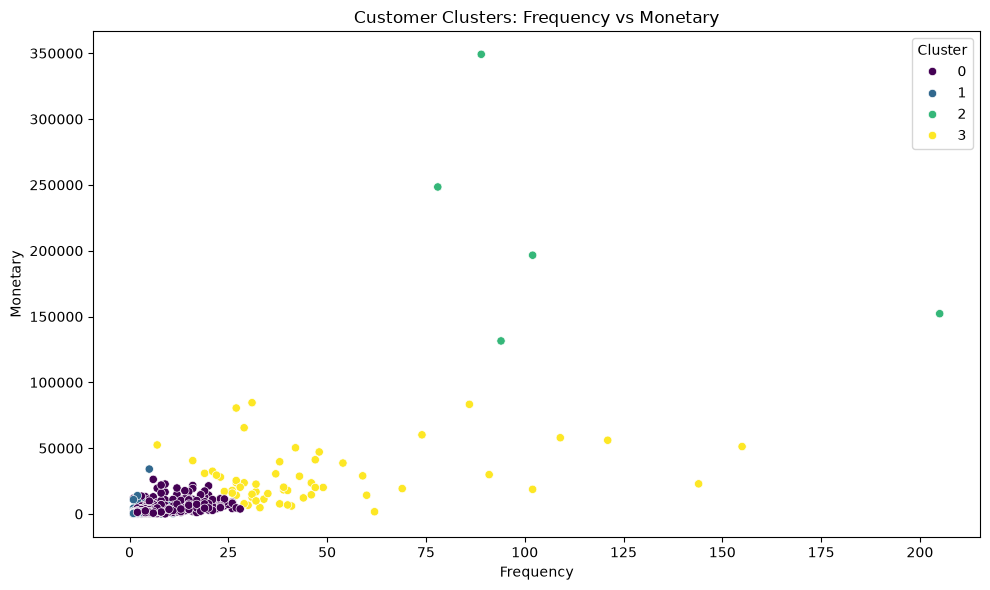

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Customer Clusters: Frequency vs Monetary')
plt.tight_layout()
plt.show()

In [24]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

cluster_profile['Count'] = rfm['Cluster'].value_counts()
cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,43.1,4.4,1710.8,3201
1,243.0,1.7,596.9,1047
2,5.6,113.6,215543.7,5
3,14.3,46.0,28018.4,59


Cluster 2 — "VIP / Champion Customers" (5 customers)
Extraordinarily active (bought just ~6 days ago on average) and place orders constantly (113.6 orders on average) with enormous total spend ($215,543 average). This is a tiny, extremely valuable group — likely wholesale buyers or major repeat clients. Losing even one of these customers would be a significant revenue hit.

Cluster 3 — "Loyal Customers" (59 customers)
Also very recently active (14.3 days) and frequent (46 orders on average), with strong spend ($28,018). A larger, still highly valuable group of consistently engaged customers — the backbone of steady repeat revenue.

Cluster 0 — "Regular/Average Customers" (3,201 customers — the largest group)
Reasonably recent (43 days) but modest frequency (4.4 orders) and spend ($1,710.80). This is your typical, everyday customer base — decent engagement, but nowhere near VIP status. This is where most of your customer base lives.

Cluster 1 — "At-Risk / Inactive Customers" (1,047 customers)
Hasn't purchased in a long time (243 days — over 8 months on average), low frequency (1.7 orders), and the lowest spend ($596.90). These customers are likely drifting away or already lost.

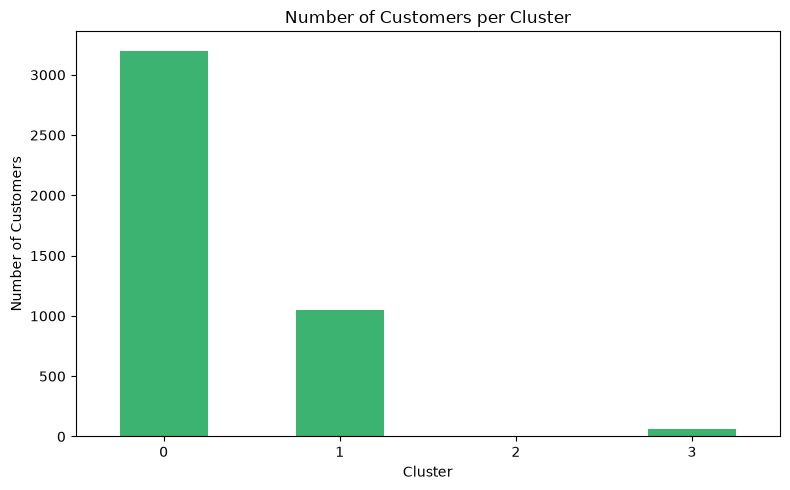

In [25]:
plt.figure(figsize=(8, 5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Cluster Size Observations
The distribution across clusters is highly imbalanced: Cluster 0 (Regular Customers) makes up the vast majority (3,201 customers), while Cluster 2 (VIP Customers) contains just 5 individuals. Despite their tiny size, these 5 VIP customers alone contribute far more revenue per person than any other group — a classic "few customers drive outsized value" pattern.

## Marketing Insights & Recommendations

### Cluster 2 — VIP / Champion Customers (5 customers)
**Profile:** Extremely frequent buyers (114 orders on average), spending over $215,000 on average, purchased within the last week.
**Recommendation:** Assign a dedicated account manager or personal point of contact. Offer exclusive early access to new products, custom pricing, or a formal loyalty/partnership program. Losing any one of these customers represents a major revenue risk — retention here should be a top priority, handled proactively rather than through generic marketing.

### Cluster 3 — Loyal Customers (59 customers)
**Profile:** Frequent buyers (46 orders on average), strong spend (~$28,000), recently active.
**Recommendation:** Nurture this group toward VIP status with a tiered loyalty program (e.g., rewards or discounts that increase with purchase frequency). Personalized product recommendations based on past purchases could increase both frequency and order value further.

### Cluster 0 — Regular Customers (3,201 customers)
**Profile:** The largest segment, moderately recent activity but low frequency and spend.
**Recommendation:** This group represents the greatest opportunity for overall revenue growth, given its size. Use targeted email campaigns, bundle deals, or limited-time offers to increase purchase frequency. Even a small increase in average order value across this group would have a large aggregate impact given its size.

### Cluster 1 — At-Risk / Inactive Customers (1,047 customers)
**Profile:** Haven't purchased in an average of 243 days, low historical frequency and spend.
**Recommendation:** Launch a win-back campaign — a personalized "we miss you" email with a time-limited discount, or a survey to understand why they stopped purchasing. Given the large size of this group (1,047 customers), even a modest reactivation rate could meaningfully recover lost revenue.